In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
elo_df = pd.read_csv('../data/processed/elo_at_wc_entry.csv')
elo_df.head()

,tournament_id,team,first_match_date,elo_at_entry,year
0,WC-1930,Argentina,1930-07-15,1794.42,1930
1,WC-1930,Belgium,1930-07-13,1459.93,1930
2,WC-1930,Bolivia,1930-07-17,1307.88,1930
3,WC-1930,Brazil,1930-07-14,1589.70,1930
4,WC-1930,Chile,1930-07-16,1376.82,1930


In [4]:
elo_df[elo_df['year'] == 2022].sort_values('elo_at_entry', ascending=False).head(10)

,tournament_id,team,first_match_date,elo_at_entry,year
429,WC-2022,Brazil,2022-11-24,2229.09,2022
426,WC-2022,Argentina,2022-11-22,2188.30,2022
452,WC-2022,Spain,2022-11-23,2097.70,2022
444,WC-2022,Netherlands,2022-11-21,2085.78,2022
428,WC-2022,Belgium,2022-11-23,2063.09,2022
446,WC-2022,Portugal,2022-11-24,2054.53,2022
437,WC-2022,France,2022-11-22,2045.40,2022
438,WC-2022,Germany,2022-11-23,2016.16,2022
434,WC-2022,Denmark,2022-11-22,2016.14,2022
456,WC-2022,Uruguay,2022-11-24,2003.77,2022


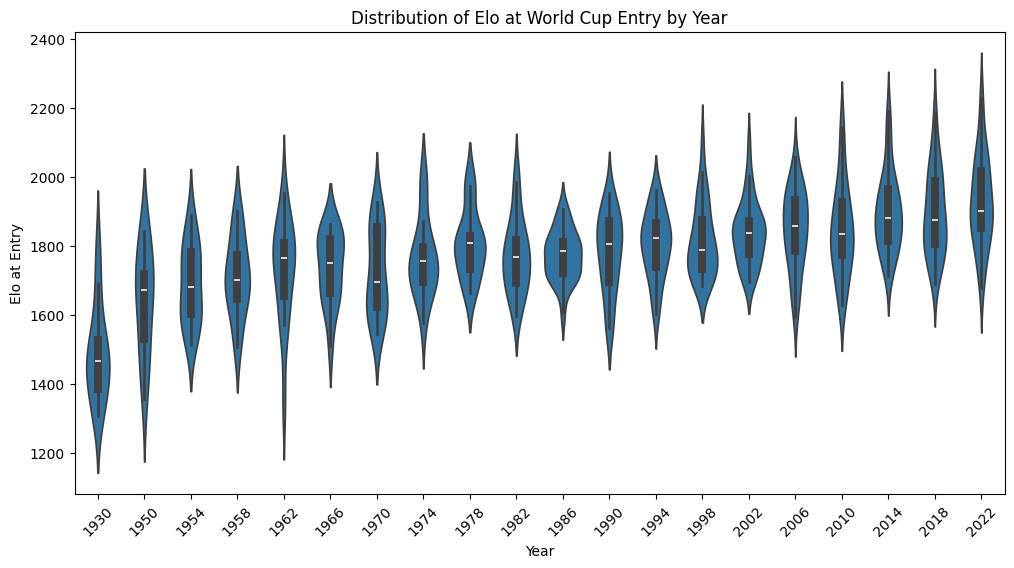

In [ ]:
# Plot violin plot of Elo at entry by year
plt.figure(figsize=(12, 6))
sns.violinplot(x='year', y='elo_at_entry', data=elo_df)
plt.title('Distribution of Elo at World Cup Entry by Year')
plt.xlabel('Year')
plt.ylabel('Elo at Entry')
plt.xticks(rotation=45)
plt.show()

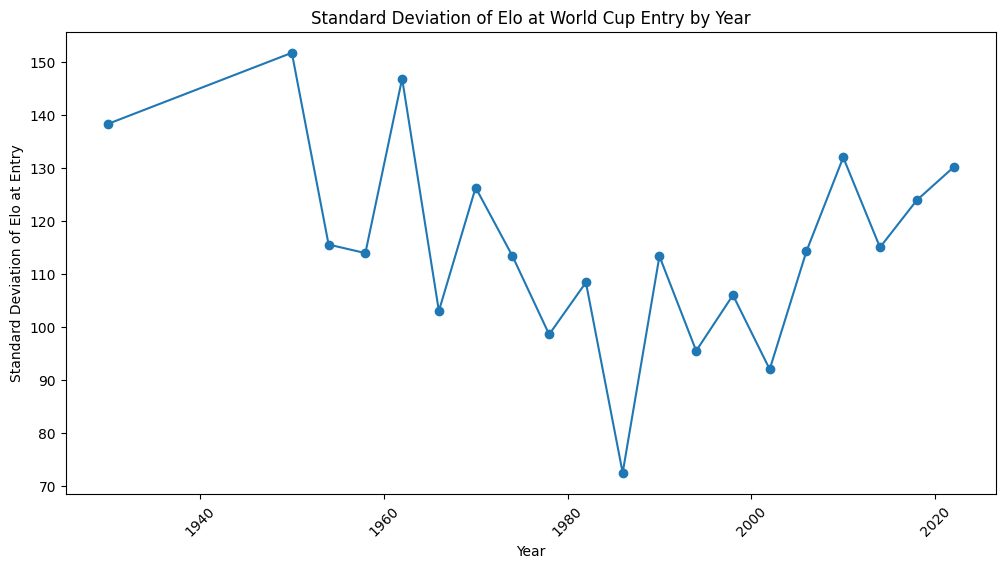

In [12]:
# Plot elo standard deviation at entry by year
std_by_year = elo_df.groupby('year')['elo_at_entry'].std().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(std_by_year['year'], std_by_year['elo_at_entry'], marker='o')
plt.title('Standard Deviation of Elo at World Cup Entry by Year')
plt.xlabel('Year')
plt.ylabel('Standard Deviation of Elo at Entry')
plt.xticks(rotation=45)
plt.show()

In [14]:
# Count number of teams per year
teams_per_year = elo_df.groupby('year')['team'].nunique().reset_index()
teams_per_year.columns = ['year', 'num_teams']
teams_per_year

,year,num_teams
0,1930,13
1,1950,13
2,1954,16
3,1958,16
4,1962,16
5,1966,16
6,1970,16
7,1974,16
8,1978,16
9,1982,24


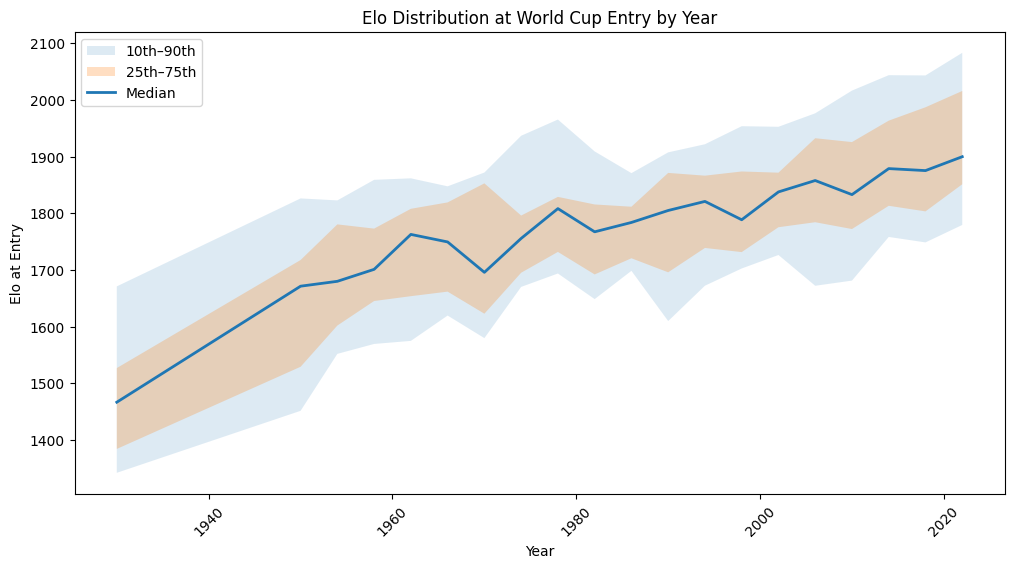

In [19]:
# Plot bottom 10% of Elo at entry by year
percentiles = elo_df.groupby('year')['elo_at_entry'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack()
percentiles.columns = ['p10', 'p25', 'p50', 'p75', 'p90']

plt.figure(figsize=(12, 6))
plt.fill_between(percentiles.index, percentiles['p10'], percentiles['p90'], alpha=0.15, label='10th–90th')
plt.fill_between(percentiles.index, percentiles['p25'], percentiles['p75'], alpha=0.25, label='25th–75th')
plt.plot(percentiles.index, percentiles['p50'], label='Median', linewidth=2)
plt.title('Elo Distribution at World Cup Entry by Year')
plt.xlabel('Year')
plt.ylabel('Elo at Entry')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [21]:
cis_df = pd.read_csv('../data/processed/cis_by_tournament.csv')

cis_df

,tournament_id,year,matches,mean_cis,median_cis,std_cis,mean_goal_diff,mean_elo_gap,draw_rate
0,WC-1930,1930,15,0.2944,0.2433,0.2302,2.4000,186.2920,0.0000
1,WC-1950,1950,22,0.3868,0.3856,0.2676,2.2727,152.4536,0.1364
2,WC-1954,1954,18,0.2902,0.1658,0.3133,3.3333,161.5100,0.1111
3,WC-1958,1958,27,0.5306,0.5031,0.2872,1.2963,150.5641,0.3704
4,WC-1962,1962,24,0.5017,0.4728,0.2445,1.5417,162.6354,0.2083
5,WC-1966,1966,24,0.5122,0.4647,0.2486,1.5000,137.7942,0.2083
6,WC-1970,1970,24,0.4799,0.5118,0.2402,1.4583,150.7396,0.2083
7,WC-1974,1974,30,0.4857,0.4788,0.3028,1.8333,133.5783,0.2667
8,WC-1978,1978,36,0.5280,0.5558,0.2475,1.4722,133.9019,0.2500
9,WC-1982,1982,48,0.5514,0.6088,0.2832,1.3958,129.5137,0.3333


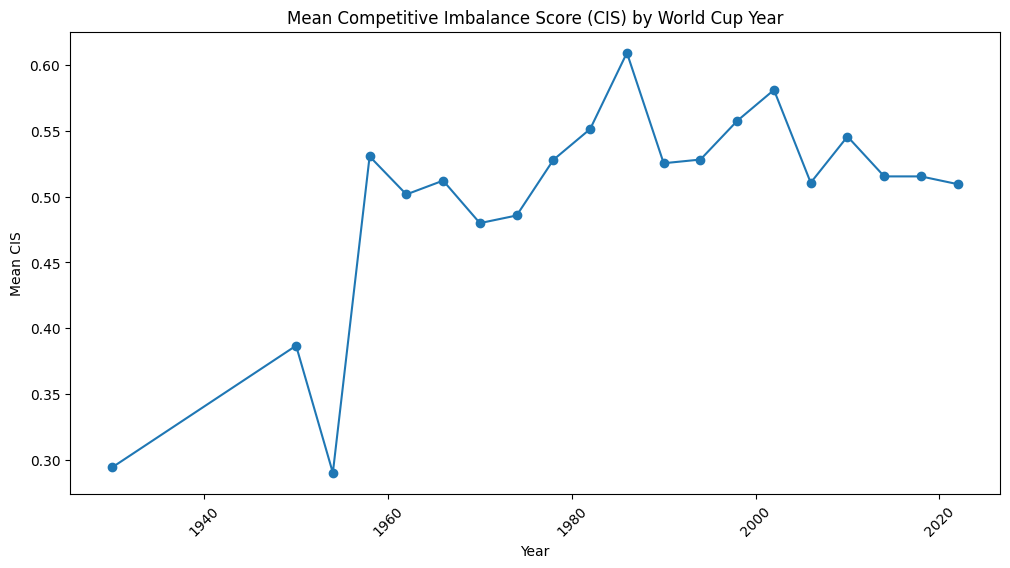

In [23]:
# Plot mean CIS by year
plt.figure(figsize=(12, 6))
plt.plot(cis_df['year'], cis_df['mean_cis'], marker='o')
plt.title('Mean Competitive Imbalance Score (CIS) by World Cup Year')
plt.xlabel('Year')
plt.ylabel('Mean CIS')
plt.xticks(rotation=45)
plt.show()